In [226]:
# Makes my own version of ScopeSim data, in order to debug my IMG OPT 03 psf quality
# test code. This uses two methods to make the PSF:
# 1. Using the "perfect" PSF (kernel) from ScopeSim and convolving with a pinhole
# 2. Using an annular aperture function and convolving with a pinhole

In [227]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import convolve_fft



In [228]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "main_scripts"))  # if cwd is dev_notebooks/
# or absolute:
# sys.path.insert(0, "/podman-share/metis_work/METIS_MAIT_code_eckhart/main_scripts")
from modules.helpers import intensity_annular_aperture

# Method 1: Use ScopeSim kernel

In [229]:
file_name_abs_kernel_scopesim = '/Users/eckhartspalding/Documents/git.repos/metis_work/METIS_MAIT_code_eckhart/data/kernels_scopesim/PSF_PPS-LM.fits'

In [230]:
# set the wavelength
# N.b. Br-alpha is 4.052 um
wavelength_m = 4.09e-6 # wavelength of PSF [m]; see header

In [231]:
# read in the kernel
hdul = fits.open(file_name_abs_kernel_scopesim)
#hdul.info()

# 16  PSF_4.01um    1 ImageHDU        23   (256, 256)   float32   
# 17  PSF_4.09um    1 ImageHDU        23   (256, 256)   float32   
# 18  PSF_4.17um    1 ImageHDU        23   (256, 256)   float32 
kernel_scopesim = hdul[17].data


In [232]:
# define the pinhole
pinhole_diam_um = 25.0 # um (25 um for LM)
# Plate scale at WCU FP2.1 [mm/asec]; Table 2.6 in E-REP-MPIA-1203
plate_scale_mm_per_asec = 3.319

pinhole_diam_asec = pinhole_diam_um * 1e-3 / plate_scale_mm_per_asec

In [233]:
# detector plate scale [mas/pix]
plate_scale_mas_per_pix = 5.47  # LM

In [234]:
# make the pinhole screen
pinhole = np.zeros(kernel_scopesim.shape)
xx, yy = np.meshgrid(np.arange(kernel_scopesim.shape[1])-kernel_scopesim.shape[1]/2, np.arange(kernel_scopesim.shape[0])-kernel_scopesim.shape[0]/2)
dist_from_center_pix = np.sqrt(xx**2 + yy**2)
dist_from_center_asec = dist_from_center_pix * (plate_scale_mas_per_pix / 1000.0)
pinhole[dist_from_center_asec < pinhole_diam_asec/2] = 1

# shift by one pixel, to match the kernel
#pinhole = np.roll(pinhole, -1, axis=0)
pinhole = np.roll(pinhole, -1, axis=[1,1])
pinhole = np.roll(pinhole, 1, axis=[1,1])

# distances in units of radians
dist_from_center_rad = dist_from_center_asec / 206265.

# convolve the pinhole screen with the kernel
psf_kernel_conv_pinhole = convolve_fft(kernel_scopesim, pinhole)

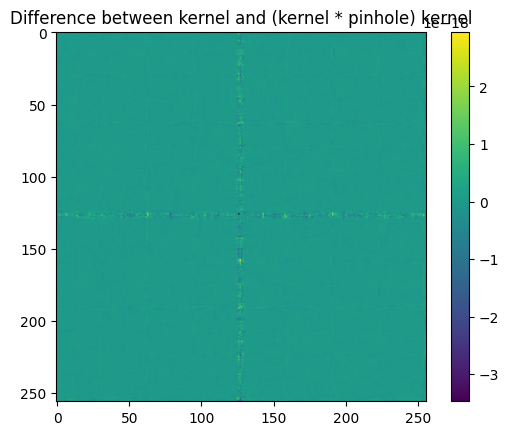

In [235]:
plt.imshow(kernel_scopesim-psf_kernel_conv_pinhole)
plt.colorbar()
plt.title('Difference between kernel and (kernel * pinhole) kernel')
plt.show()

In [236]:
# call the analytical annular PSF function
# import intensity_annular_aperture() from helpers.py

# define the annular aperture parameters
#from METIS_MAIT_code_eckhart.misc.debug_annular_aperture import D_obscuration

annulus_inner_diam_m = 12.8502
annulus_outer_diam_m = 34.6878


# make the annular aperture function
annulus_analytical_psf = intensity_annular_aperture(
    r_rad_array=dist_from_center_rad, 
    wavel=wavelength_m,
    D_obscuration = annulus_inner_diam_m, 
    D_aperture = annulus_outer_diam_m, 
    pinhole_diam_rad=None
    )

# shift by one pixel, to match the kernel
annulus_analytical_psf = np.roll(annulus_analytical_psf, -1, axis=0)
annulus_analytical_psf = np.roll(annulus_analytical_psf, -1, axis=1)

# convolve the annular aperture function with the pinhole
psf_analytical_conv_pinhole = convolve_fft(annulus_analytical_psf, pinhole)

In [237]:
# normalize for comparison

psf_analytical_conv_pinhole = psf_analytical_conv_pinhole / np.max(psf_analytical_conv_pinhole)
kernel_scopesim = kernel_scopesim / np.max(kernel_scopesim)
annulus_analytical_psf = annulus_analytical_psf / np.max(annulus_analytical_psf)

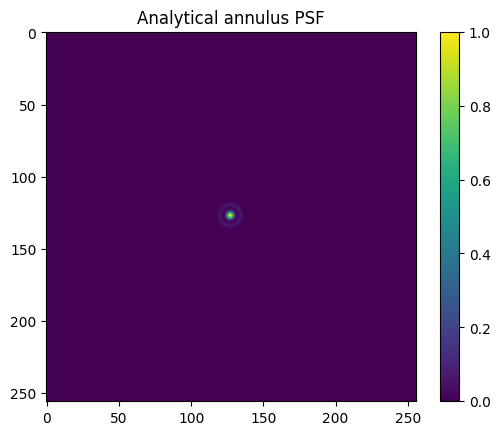

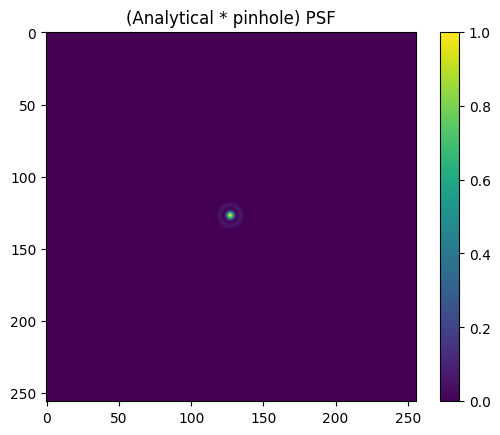

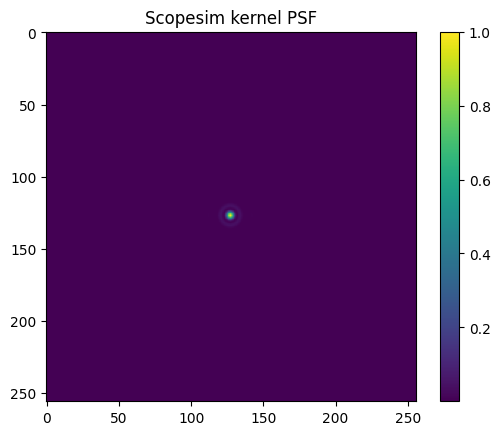

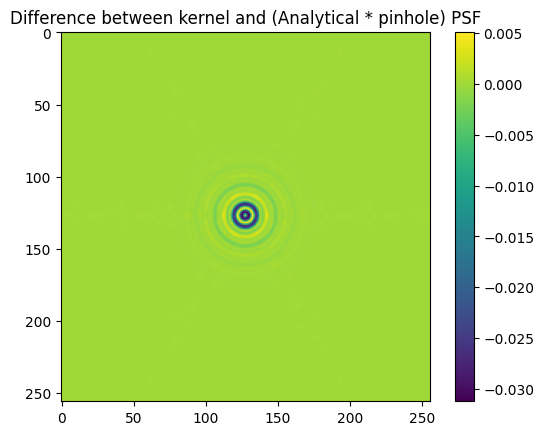

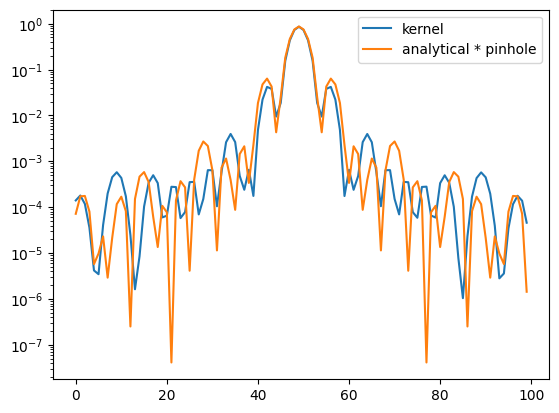

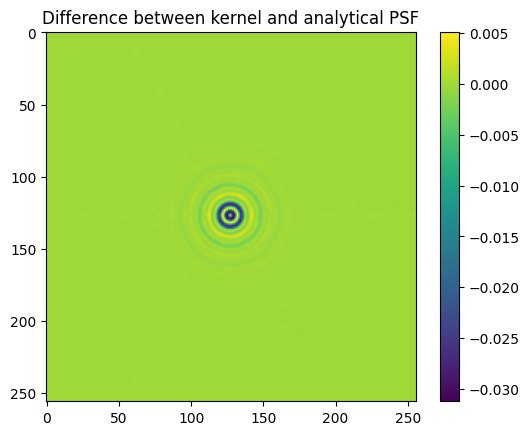

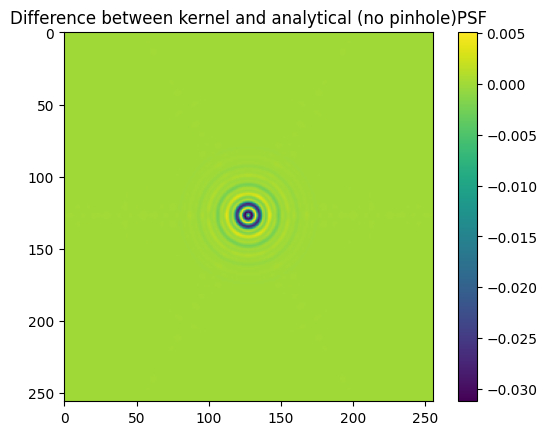

In [ ]:
plt.clf()
plt.imshow(annulus_analytical_psf)
plt.colorbar()
plt.title('Analytical annulus PSF')
plt.show()

plt.clf()
plt.imshow(psf_analytical_conv_pinhole)
plt.colorbar()
plt.title('(Analytical * pinhole) PSF')
plt.show()

plt.clf()
plt.imshow(kernel_scopesim)
plt.colorbar()
plt.title('Scopesim kernel PSF')
plt.show()

plt.clf()
plt.imshow(kernel_scopesim-psf_analytical_conv_pinhole)
plt.colorbar()
plt.title('Difference between kernel and (Analytical * pinhole) PSF')
plt.show()

# make 1D plots through the centers of kernel_scopesim and annulus_analytical_psf
plt.clf()
# just plot the central 100 pixels
span = 100
idx1 = kernel_scopesim.shape[1]//2-int(span/2)
idx2 = kernel_scopesim.shape[1]//2+int(span/2)
plt.plot(psf_kernel_conv_pinhole[psf_kernel_conv_pinhole.shape[0]//2, idx1:idx2])
plt.plot(psf_analytical_conv_pinhole[psf_analytical_conv_pinhole.shape[0]//2, idx1:idx2])
plt.yscale('log')
plt.legend(['kernel * pinhole', 'analytical * pinhole'])
plt.show()

plt.clf()
plt.imshow(kernel_scopesim-annulus_analytical_psf)
plt.colorbar()
plt.title('Difference between kernel and analytical PSF')
plt.show()

# make 1D plots through the centers of kernel_scopesim and annulus_analytical_psf
plt.clf()
# just plot the central 100 pixels
span = 50
idx1 = kernel_scopesim.shape[1]//2-int(span/2)
idx2 = kernel_scopesim.shape[1]//2+int(span/2)
plt.plot(kernel_scopesim[kernel_scopesim.shape[0]//2, idx1:idx2])
plt.plot(annulus_analytical_psf[annulus_analytical_psf.shape[0]//2, idx1:idx2])
plt.yscale('log')
plt.legend(['kernel', 'analytical'])
plt.savefig('junk_kernel_and_analytical_psf_1d_comparison.png')

plt.clf()
plt.imshow(kernel_scopesim-annulus_analytical_psf)
plt.colorbar()
plt.title('Difference between kernel and analytical (no pinhole)PSF')
plt.show('junk_kernel_and_analytical_psf_2d_residuals.png')

In [239]:
print(np.unravel_index(np.nanargmax(kernel_scopesim), kernel_scopesim.shape))
print(np.unravel_index(np.nanargmax(annulus_analytical_psf), annulus_analytical_psf.shape))
print(np.unravel_index(np.nanargmax(pinhole), pinhole.shape))


(127, 127)
(127, 127)
(128, 128)
